In [2]:
import os
import torch
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from sae_all import GatedSparseAutoencoder

os.environ["HF_HOME"] = "models"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [3]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_name = "gpt2"
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name, output_hidden_states=True)
model = model.to(device)
model.eval()
tokenizer.pad_token = tokenizer.eos_token

W_U = model.lm_head.weight.detach()
print("W_U shape:", W_U.shape)

/Users/armaanjagirdar/Projects/SAE_GPT2/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11560.58it/s]


W_U shape: torch.Size([50257, 768])


In [4]:
INPUT_DIM = 768
LATENT_DIM = 2048

sae = GatedSparseAutoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM).to(device)
sae.load_state_dict(torch.load("models/sae_trained/gated_sae.pt", map_location=device))
sae.eval()
print("Loaded sae weights successfully")

Loaded sae weights successfully


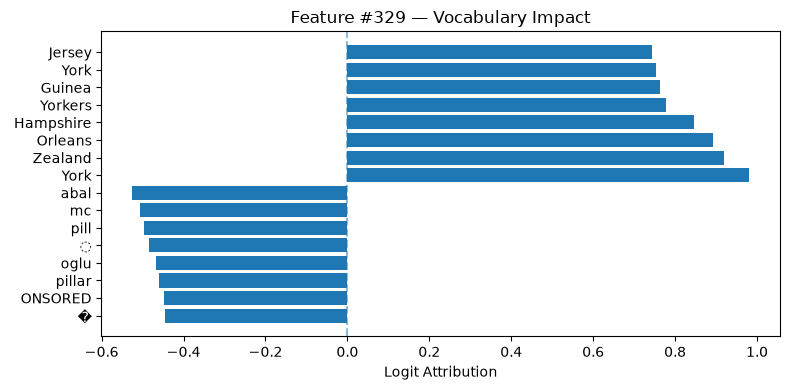

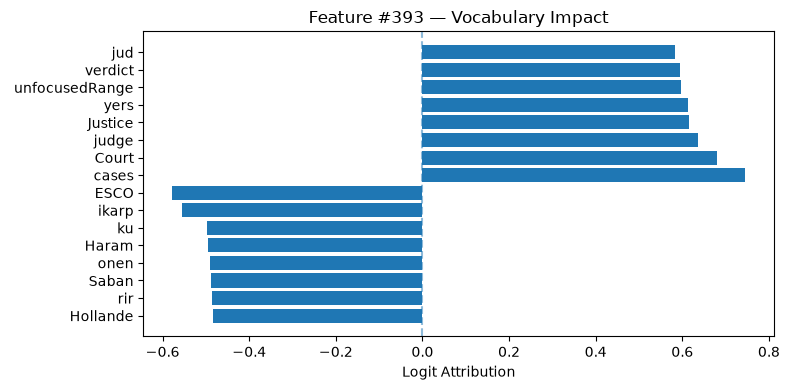

In [5]:
def inspect_feature_logits(feature_id, top_n=8):
    d_k = sae.decoder.weight[:, feature_id].detach()
    logits = torch.matmul(W_U, d_k)

    top_v, top_i = torch.topk(logits, k=top_n)
    bot_v, bot_i = torch.topk(logits, k=top_n, largest=False)

    top_tokens = [repr(tokenizer.decode([idx.item()])).strip("'") for idx in top_i]
    bot_tokens = [repr(tokenizer.decode([idx.item()])).strip("'") for idx in bot_i]

    tokens = bot_tokens[::-1] + top_tokens
    reversed_bot_v = torch.flip(bot_v, dims=[0])
    values = [v.item() for v in reversed_bot_v] + [v.item() for v in top_v]

    _, ax = plt.subplots(figsize=(8, 4))
    ax.barh(range(len(tokens)), values)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens)
    ax.axvline(0, linestyle="--", alpha=0.5)
    ax.set_title(f"Feature #{feature_id} — Vocabulary Impact")
    ax.set_xlabel("Logit Attribution")
    plt.tight_layout()
    plt.show()

inspect_feature_logits(329, top_n=8)
inspect_feature_logits(393, top_n=8)

In [6]:
W_dec = sae.decoder.weight.detach()
all_logits = torch.matmul(W_dec.T, W_U.T)

top3_vals, top3_indices = torch.topk(all_logits, k=3, dim=-1)

feature_catalog = []
for feat_id in range(LATENT_DIM):
    top_toks = [tokenizer.decode([top3_indices[feat_id, k].item()]).strip() for k in range(3)]
    max_logit = top3_vals[feat_id, 0].item()
    feature_catalog.append({
        "feature_id": feat_id,
        "top_promoted_tokens": " • ".join(top_toks),
        "max_logit": round(max_logit, 3)
    })

df_catalog = pd.DataFrame(feature_catalog)
df_top = df_catalog.sort_values(by="max_logit", ascending=False).head(10).reset_index(drop=True)
df_top

,feature_id,top_promoted_tokens,max_logit
0,536,s • sburg • sb,2.045
1,861,respectively • alike • depending,1.789
2,32,ing • ed • ation,1.639
3,1818,rd • RD • peat,1.604
4,829,anymore • nor • whatsoever,1.579
5,945,than • than • Than,1.545
6,1797,worldly • wise • kinds,1.530
7,1535,) • ?) • ?).,1.526
8,1128,sake • purposes • reasons,1.505
9,843,own • Own • favorite,1.497


In [7]:
def find_features_for_token(query_word, top_n=2):
    token_ids = tokenizer.encode(query_word)
    if not token_ids:
        return []

    target_id = token_ids[0]
    token_str = tokenizer.decode([target_id])
    token_logits = all_logits[:, target_id]
    top_vals, top_fids = torch.topk(token_logits, k=top_n)

    results = []
    for rank, (val, fid) in enumerate(zip(top_vals, top_fids)):
        results.append({
            "query_word": repr(token_str),
            "rank": f"#{rank+1}",
            "feature_id": fid.item(),
            "logit_boost": round(val.item(), 3),
            "co_promoted_tokens": df_catalog.iloc[fid.item()]["top_promoted_tokens"]
        })
    return results

queries = [" York", " Court", " because", " 19", " said", " activist"]
search_rows = []
for q in queries:
    search_rows.extend(find_features_for_token(q, top_n=2))

df_search = pd.DataFrame(search_rows)
df_search

,query_word,rank,feature_id,logit_boost,co_promoted_tokens
0,' York',#1,329,0.981,York • Zealand • Orleans
1,' York',#2,2026,0.621,bies • bie • arrivals
2,' Court',#1,914,0.560,Manager • Aid • Services
3,' Court',#2,1222,0.545,Fathers • Gazette • Library
4,' because',#1,1438,0.472,notion • bigotry • encro
5,' because',#2,375,0.446,albeit • namely • although
6,' 19',#1,374,0.659,8 • 9 • 2
7,' 19',#2,951,0.369,fair • morning • 2017
8,' said',#1,912,0.424,recommends • conclud • speculate
9,' said',#2,1495,0.389,spokesman • engineers • has


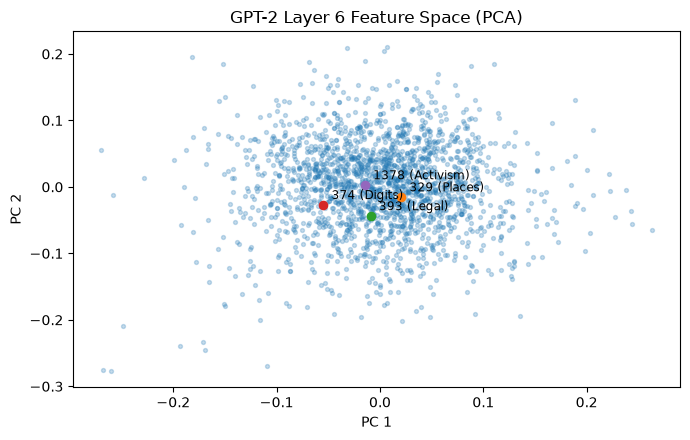

In [8]:
W_dec_norm = W_dec.T - W_dec.T.mean(dim=0, keepdim=True)
U, S, V = torch.pca_lowrank(W_dec_norm, q=2)
coords_2d = torch.matmul(W_dec_norm, V[:, :2]).cpu().numpy()

plt.figure(figsize=(7, 4.5))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.25, s=8)

landmarks = [(329, "329 (Places)"), (393, "393 (Legal)"), (374, "374 (Digits)"), (1378, "1378 (Activism)")]
for fid, label in landmarks:
    x, y = coords_2d[fid, 0], coords_2d[fid, 1]
    plt.scatter(x, y, s=35)
    plt.annotate(label, (x, y), xytext=(6, 4), textcoords="offset points", fontsize=8.5)

plt.title("GPT-2 Layer 6 Feature Space (PCA)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

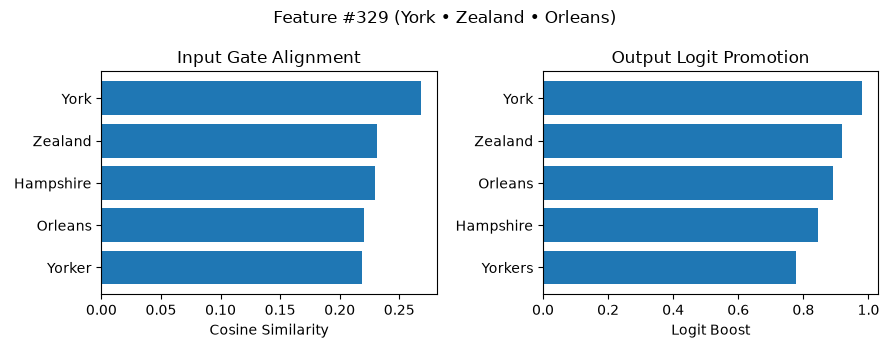

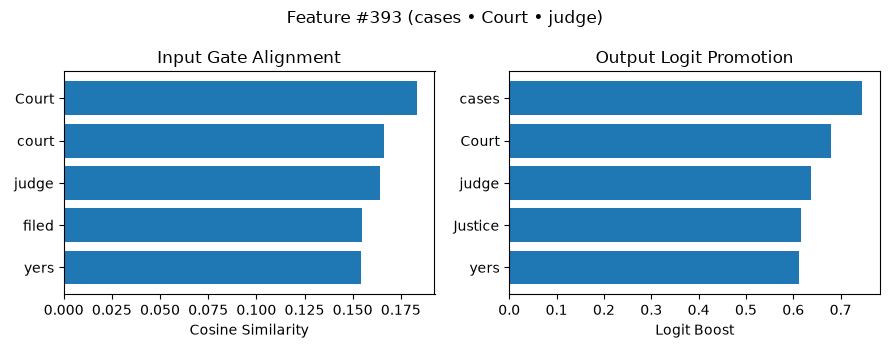

In [9]:
def compare_input_output(feature_id, top_n=5):
    d_k = sae.decoder.weight[:, feature_id].detach()
    logits = torch.matmul(W_U, d_k)
    top_logits, top_log_indices = torch.topk(logits, k=top_n)
    out_tokens = [repr(tokenizer.decode([idx.item()])).strip("'") for idx in top_log_indices]
    out_scores = [val.item() for val in top_logits]

    W_E = model.transformer.wte.weight.detach()
    gate_dir = sae.encoder_gate.weight[feature_id, :].detach()
    gate_norm = F.normalize(gate_dir, dim=0)
    w_e_norm = F.normalize(W_E, dim=1)
    cos_sims = torch.matmul(w_e_norm, gate_norm)
    top_sims, top_sim_indices = torch.topk(cos_sims, k=top_n)
    in_tokens = [repr(tokenizer.decode([idx.item()])).strip("'") for idx in top_sim_indices]
    in_scores = [sim.item() for sim in top_sims]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

    y_pos = range(top_n)[::-1]
    ax1.barh(y_pos, in_scores)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(in_tokens)
    ax1.set_title("Input Gate Alignment")
    ax1.set_xlabel("Cosine Similarity")

    ax2.barh(y_pos, out_scores)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(out_tokens)
    ax2.set_title("Output Logit Promotion")
    ax2.set_xlabel("Logit Boost")

    toks = df_catalog.iloc[feature_id]["top_promoted_tokens"]
    plt.suptitle(f"Feature #{feature_id} ({toks})")
    plt.tight_layout()
    plt.show()

compare_input_output(329)
compare_input_output(393)